In [158]:
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo
from pyomo.environ import SolverFactory
from pyomo.environ import *
import random



## 1. Gerar Grid

In [159]:
linha = 5

grid = np.zeros((linha,linha,linha))

for i in range(linha):
    for j in range(linha):
        for k in range(linha):
        # grid[i,j] = np.random.choice([1,10,100,1000,10000])
            # grid[i,j,k] = np.random.choice([1,10,11,1,12])
            grid[i,j,k] = np.random.choice([1,11,2,15,100,0])
# grid[1,1,1] = 1



print(grid)

[[[  1.  11.   1.   2.   1.]
  [100.  11. 100. 100.   1.]
  [ 15.  15.   2.   2.   1.]
  [  1.  15.  11.   2. 100.]
  [  1.   1.  11.   2. 100.]]

 [[  0.   1.  15. 100. 100.]
  [  2. 100.   2.   1.   1.]
  [ 11.   2. 100. 100.   0.]
  [100.  15.   2.   0.   2.]
  [ 11.  11. 100.  11.  15.]]

 [[ 15.   0.   2.   0.   1.]
  [ 11.  15.   2.  15.  15.]
  [  2.   1. 100.   2. 100.]
  [ 11.   1.   1.   0.  15.]
  [100.  11.   0.  15.  15.]]

 [[  0.  11.   1.   2.   1.]
  [  0.  15.   1.   0.  15.]
  [ 15.  15.  11.   0.   2.]
  [  2. 100.   2.  11.   0.]
  [100.   1.   0.   1. 100.]]

 [[  1. 100.   2.   0. 100.]
  [  1.  15.   1.   1.   0.]
  [  2.  15.   1.   0. 100.]
  [  1.   0.  15.   2. 100.]
  [  0.   2. 100.  15.  15.]]]


### 2. Buscar vizinhos

In [160]:
vizinhos = {}
for i in range(linha):
    for j in range(linha):
        for k in range(linha):
            lista_viz_total = []
            cima = [i,j,k-1]
            baixo = [i,j,k+1]
            direita = [i+1,j,k]
            esquerda = [i-1,j,k]
            dentro = [i,j-1,k]
            retorno = [i,j+1,k]
            lista_viz_total.append(cima)
            lista_viz_total.append(baixo)
            lista_viz_total.append(direita)
            lista_viz_total.append(esquerda)
            lista_viz_total.append(dentro)
            lista_viz_total.append(retorno)

            lista_v=[]
            for v in lista_viz_total:
                x = v[0]
                y = v[1]
                z = v[2]
                if x>=0 and x<=linha-1 and y>=0 and y<=linha-1 and z>=0 and z<=linha-1:
                    lista_v.append([x,y,z])
            vizinhos[i,j,k] = lista_v

In [161]:
vizinhos

{(0, 0, 0): [[0, 0, 1], [1, 0, 0], [0, 1, 0]],
 (0, 0, 1): [[0, 0, 0], [0, 0, 2], [1, 0, 1], [0, 1, 1]],
 (0, 0, 2): [[0, 0, 1], [0, 0, 3], [1, 0, 2], [0, 1, 2]],
 (0, 0, 3): [[0, 0, 2], [0, 0, 4], [1, 0, 3], [0, 1, 3]],
 (0, 0, 4): [[0, 0, 3], [1, 0, 4], [0, 1, 4]],
 (0, 1, 0): [[0, 1, 1], [1, 1, 0], [0, 0, 0], [0, 2, 0]],
 (0, 1, 1): [[0, 1, 0], [0, 1, 2], [1, 1, 1], [0, 0, 1], [0, 2, 1]],
 (0, 1, 2): [[0, 1, 1], [0, 1, 3], [1, 1, 2], [0, 0, 2], [0, 2, 2]],
 (0, 1, 3): [[0, 1, 2], [0, 1, 4], [1, 1, 3], [0, 0, 3], [0, 2, 3]],
 (0, 1, 4): [[0, 1, 3], [1, 1, 4], [0, 0, 4], [0, 2, 4]],
 (0, 2, 0): [[0, 2, 1], [1, 2, 0], [0, 1, 0], [0, 3, 0]],
 (0, 2, 1): [[0, 2, 0], [0, 2, 2], [1, 2, 1], [0, 1, 1], [0, 3, 1]],
 (0, 2, 2): [[0, 2, 1], [0, 2, 3], [1, 2, 2], [0, 1, 2], [0, 3, 2]],
 (0, 2, 3): [[0, 2, 2], [0, 2, 4], [1, 2, 3], [0, 1, 3], [0, 3, 3]],
 (0, 2, 4): [[0, 2, 3], [1, 2, 4], [0, 1, 4], [0, 3, 4]],
 (0, 3, 0): [[0, 3, 1], [1, 3, 0], [0, 2, 0], [0, 4, 0]],
 (0, 3, 1): [[0, 3, 0], [0, 

### ARCOS CUSTO

In [162]:
arco_custo = {}
custo_passo = 1
for k,v in vizinhos.items():
    
    
    for vv in v:
        
        
        arco_custo[(k[0],k[1],k[2]),(vv[0],vv[1],vv[2])] = grid[k[0],k[1],k[2]] + grid[vv[0],vv[1],vv[2]] + custo_passo

## MATRIZ B

In [163]:

origem = (0,0,0)
destino = (linha-2,linha-2,linha-2)
lista_origem = []
di_matriz_b = {}
for k in vizinhos.keys():
    di_matriz_b[k] = 0

di_matriz_b[origem] = -1
di_matriz_b[3,1,1]=-1
# di_matriz_b[1,2,1]=-1
lista_origem.append([3,1,1])
# lista_origem.append([1,2,1])
di_matriz_b[destino]=+2

di_matriz_b


{(0, 0, 0): -1,
 (0, 0, 1): 0,
 (0, 0, 2): 0,
 (0, 0, 3): 0,
 (0, 0, 4): 0,
 (0, 1, 0): 0,
 (0, 1, 1): 0,
 (0, 1, 2): 0,
 (0, 1, 3): 0,
 (0, 1, 4): 0,
 (0, 2, 0): 0,
 (0, 2, 1): 0,
 (0, 2, 2): 0,
 (0, 2, 3): 0,
 (0, 2, 4): 0,
 (0, 3, 0): 0,
 (0, 3, 1): 0,
 (0, 3, 2): 0,
 (0, 3, 3): 0,
 (0, 3, 4): 0,
 (0, 4, 0): 0,
 (0, 4, 1): 0,
 (0, 4, 2): 0,
 (0, 4, 3): 0,
 (0, 4, 4): 0,
 (1, 0, 0): 0,
 (1, 0, 1): 0,
 (1, 0, 2): 0,
 (1, 0, 3): 0,
 (1, 0, 4): 0,
 (1, 1, 0): 0,
 (1, 1, 1): 0,
 (1, 1, 2): 0,
 (1, 1, 3): 0,
 (1, 1, 4): 0,
 (1, 2, 0): 0,
 (1, 2, 1): 0,
 (1, 2, 2): 0,
 (1, 2, 3): 0,
 (1, 2, 4): 0,
 (1, 3, 0): 0,
 (1, 3, 1): 0,
 (1, 3, 2): 0,
 (1, 3, 3): 0,
 (1, 3, 4): 0,
 (1, 4, 0): 0,
 (1, 4, 1): 0,
 (1, 4, 2): 0,
 (1, 4, 3): 0,
 (1, 4, 4): 0,
 (2, 0, 0): 0,
 (2, 0, 1): 0,
 (2, 0, 2): 0,
 (2, 0, 3): 0,
 (2, 0, 4): 0,
 (2, 1, 0): 0,
 (2, 1, 1): 0,
 (2, 1, 2): 0,
 (2, 1, 3): 0,
 (2, 1, 4): 0,
 (2, 2, 0): 0,
 (2, 2, 1): 0,
 (2, 2, 2): 0,
 (2, 2, 3): 0,
 (2, 2, 4): 0,
 (2, 3, 0): 0,
 (2, 3, 1

## MODELO

In [164]:
model = pyo.ConcreteModel()

model.k_nomes = pyo.Set(initialize = list(di_matriz_b.keys()))
model.arcos_nomes = pyo.Set(initialize = list(arco_custo.keys()))
model.arcos_c = pyo.Param(model.arcos_nomes,initialize=arco_custo)
model.x = pyo.Var(model.arcos_nomes, domain=pyo.Binary)

In [165]:
model.pprint()

2 Set Declarations
    arcos_nomes : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     6 :    Any :  600 : {(0, 0, 0, 0, 0, 1), (0, 0, 0, 1, 0, 0), (0, 0, 0, 0, 1, 0), (0, 0, 1, 0, 0, 0), (0, 0, 1, 0, 0, 2), (0, 0, 1, 1, 0, 1), (0, 0, 1, 0, 1, 1), (0, 0, 2, 0, 0, 1), (0, 0, 2, 0, 0, 3), (0, 0, 2, 1, 0, 2), (0, 0, 2, 0, 1, 2), (0, 0, 3, 0, 0, 2), (0, 0, 3, 0, 0, 4), (0, 0, 3, 1, 0, 3), (0, 0, 3, 0, 1, 3), (0, 0, 4, 0, 0, 3), (0, 0, 4, 1, 0, 4), (0, 0, 4, 0, 1, 4), (0, 1, 0, 0, 1, 1), (0, 1, 0, 1, 1, 0), (0, 1, 0, 0, 0, 0), (0, 1, 0, 0, 2, 0), (0, 1, 1, 0, 1, 0), (0, 1, 1, 0, 1, 2), (0, 1, 1, 1, 1, 1), (0, 1, 1, 0, 0, 1), (0, 1, 1, 0, 2, 1), (0, 1, 2, 0, 1, 1), (0, 1, 2, 0, 1, 3), (0, 1, 2, 1, 1, 2), (0, 1, 2, 0, 0, 2), (0, 1, 2, 0, 2, 2), (0, 1, 3, 0, 1, 2), (0, 1, 3, 0, 1, 4), (0, 1, 3, 1, 1, 3), (0, 1, 3, 0, 0, 3), (0, 1, 3, 0, 2, 3), (0, 1, 4, 0, 1, 3), (0, 1, 4, 1, 1, 4), (0, 1, 4, 0, 0, 4), (0, 1, 4, 0, 2, 4), (0, 2, 0, 0, 2, 1)

In [166]:
# OBjetivo

def func_obj(model):
    return sum(model.x[a] * model.arcos_c[a] for a in model.arcos_nomes)

model.obj = pyo.Objective(rule=func_obj, sense=pyo.minimize)

#REst Entra Sai

def func_rest(model, i,j,k):

    entra = sum(model.x[l,m,n,i,j,k] for l,m,n in vizinhos[i,j,k])
    sai = sum(model.x[i,j,k,l,m,n] for l,m,n in vizinhos[i,j,k])
    return entra - sai == di_matriz_b[i,j,k]

model.rest = pyo.Constraint(model.k_nomes, rule=func_rest)


In [167]:
opt = SolverFactory('cplex', executable='C:\\Program Files\\IBM\\ILOG\\CPLEX_Studio_Community222\\cplex\\bin\\x64_win64\\cplex.exe')
res = opt.solve(model)

## REsultados

In [168]:
resultado = []
for arco in arco_custo.keys():
    if pyo.value(model.x[arco]) ==1:
        resultado.append([arco[0],arco[1]])

In [169]:
resultado

[[(0, 0, 0), (1, 0, 0)],
 [(1, 0, 0), (1, 0, 1)],
 [(1, 0, 1), (2, 0, 1)],
 [(2, 0, 1), (2, 0, 2)],
 [(2, 0, 2), (2, 0, 3)],
 [(2, 0, 3), (3, 0, 3)],
 [(3, 0, 3), (4, 0, 3)],
 [(3, 1, 1), (3, 1, 2)],
 [(3, 1, 2), (3, 1, 3)],
 [(3, 1, 3), (3, 2, 3)],
 [(3, 2, 3), (3, 3, 3)],
 [(4, 0, 3), (4, 1, 3)],
 [(4, 1, 3), (4, 2, 3)],
 [(4, 2, 3), (4, 3, 3)],
 [(4, 3, 3), (3, 3, 3)]]

## Plotagem

In [170]:
print(pyo.value(model.obj))

71.0


(0, 0, 0) (1, 0, 0)
(1, 0, 0) (1, 0, 1)
(1, 0, 1) (2, 0, 1)
(2, 0, 1) (2, 0, 2)
(2, 0, 2) (2, 0, 3)
(2, 0, 3) (3, 0, 3)
(3, 0, 3) (4, 0, 3)
(3, 1, 1) (3, 1, 2)
(3, 1, 2) (3, 1, 3)
(3, 1, 3) (3, 2, 3)
(3, 2, 3) (3, 3, 3)
(4, 0, 3) (4, 1, 3)
(4, 1, 3) (4, 2, 3)
(4, 2, 3) (4, 3, 3)
(4, 3, 3) (3, 3, 3)


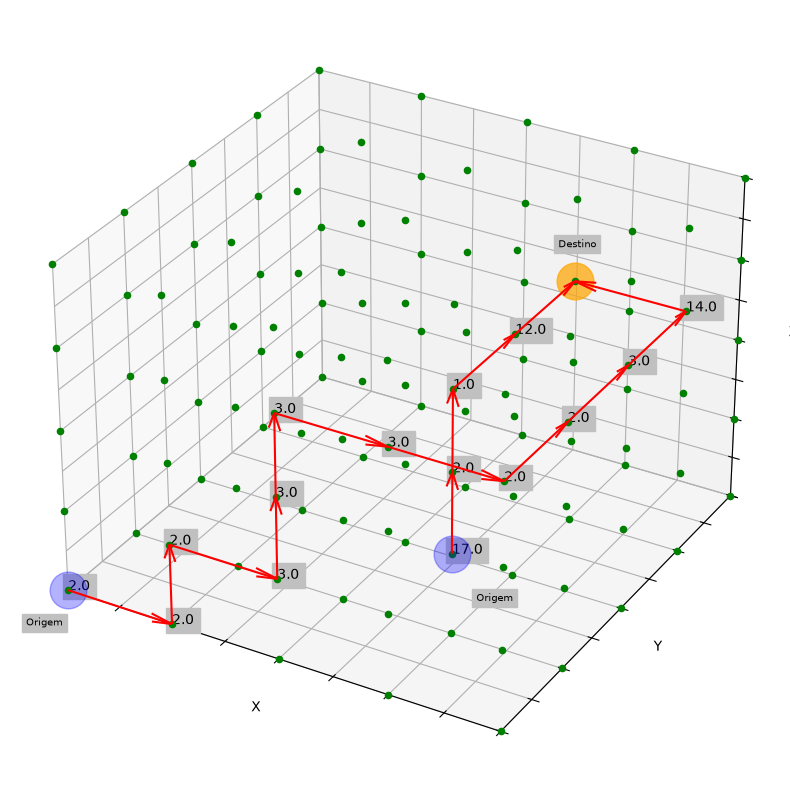

In [171]:
# Generate a mock (N, 3) spatial coordinate array

# Initialize 3D axes
fig = plt.figure(figsize=(linha*2,linha*2))
ax = fig.add_subplot(projection='3d')

# ax.scatter(linha,linha,linha)
# Plot points
# for i in range(linha):
#     for j in range(linha):
#         for k in range(linha):
#             # ax.scatter(i,j,k,color='red', marker='o', s=10)

origem=0
destino = linha-2
ax.scatter(origem,origem,origem, marker='o',s=700,alpha=0.55,color='blue')
ax.text(origem,origem-0.6,origem,"Origem",color='black',backgroundcolor='silver',size=7)
ax.scatter(destino,destino,destino, marker='o',s=700,alpha=0.85,color='orange')
ax.text(destino,destino-0.3,destino+0.6,"Destino",color='black',backgroundcolor='silver',size=7)
for item in list(vizinhos.items()):
    celula = item[0]
    # ax.text(celula[0],celula[1],celula[2]-0.2,(celula[0],celula[1],celula[2]),backgroundcolor='white',size=7)
    ax.scatter(celula[0],celula[1],celula[2],color='green', marker='o', s=20)
    v_celula = item[1]
    for vc in v_celula:
        # princelula[0],celula[1],celula[2]t(vc)
        # ax.scatter(celula[0]+np.random.choice([-0.01,-0.12,0.013,0.14]),celula[1]-np.random.choice([-0.01,0.012,-0.13,0.14]),celula[2]-np.random.choice([-0.1,0.012,0.13,-0.014]),color='red', marker='o', s=5,alpha=0.75)
        pass
for caminho in resultado:
    ori = caminho[0]
    des = caminho[1]
    dx = des[0]-ori[0]
    dy = des[1]-ori[1]
    dz = des[2]-ori[2]
    print(ori, des)
    ax.quiver(ori[0],ori[1],ori[2],dx,dy,dz, color='red', arrow_length_ratio=0.2)
    ax.text(ori[0],ori[1],ori[2],arco_custo[caminho[0],caminho[1]],color='black',backgroundcolor='silver',size=10)

for oor in lista_origem:
    ax.scatter(oor[0],oor[1],oor[2],marker='o', s=700,alpha=0.55,color='blue')
    ax.text(oor[0]+0.5,oor[1]-0.5,oor[2],"Origem",color='black',backgroundcolor='silver',size=7)

ax.set_xbound(0,linha-1)            
ax.set_ybound(0,linha-1)            
ax.set_zbound(0,linha-1)  
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.tick_params(labelbottom=False,labeltop=False,labelleft=False, labelright=False)
ax.grid(True)

plt.show()